
 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-1 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Running new simulation for ***Vector Cell Model*** with distortion=stretch-global (a=1, b=1)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	N_fvc=12500 (VCM)
	cvc_pos=[[0.         0.04411894 0.07934294],...,[497.29175374 498.64587687 500.        ]] (VCM)
	fvc_pos=[[0.        0.0400032 0.0800064],...,[499.9199936 499.9599968 500.       ]] (VCM)
	Scales=[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
	hexagonal_projection: True


Simulating trials: 100%|██████████| 100/100 [04:23<00:00,  2.64s/it]


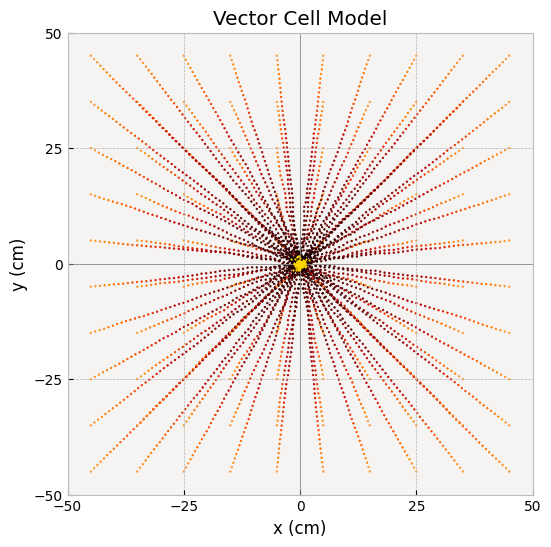

Successful trials: 100/100 (100.0%)


In [2]:
import numpy as np
from math import pow
import matplotlib.pyplot as plt
plt.style.use('bmh')
# Set background color to antique white
plt.rcParams['axes.facecolor'] = "#F5F4F2"
import os
from utils import *
from utils import grid_to_real_projection
from simulation import *
from tqdm import tqdm
from pprint import pprint

from models import DistanceCellModel, VectorCellModel, NestedModel
from simulation import run_load_simulation
OUTPUT_DIR = 'simulation_outputs'
# ================= MODEL & SIMULATION PARAMETERS =================
N_SIM_ROUND = 5
N_TRIALS = 100
ARENA_WIDTH = 100
STEP_SIZE = 1
CONV_THRESH = STEP_SIZE * 1.5
HEX_PROJ=True
model_names = ['nm', 'dcm', 'vcm']
# ----------------------------------------------------------------#
N_SIM_ROUND = 8
N_TRIALS = 100
stretch_global_params = get_param_dict({'a': [1], 'b': [1]}, 
                                       'stretch-global', incl_undistorted=False)
selected_distortion_params = stretch_global_params
for distortion_name in selected_distortion_params.keys():
    print(F'\n {"-+" * 30} RUNNING SIMULATIONS FOR DISTORTION={distortion_name} {"-+" * 30}')
    for model_name in ['vcm']:
        x_histories, y_histories = run_load_simulation(model_name, 
                                                    arena_width=ARENA_WIDTH, 
                                                    step_size=STEP_SIZE,
                                                    convergence_threshold=CONV_THRESH,
                                                    n_trials=N_TRIALS, 
                                                    distortion_params=selected_distortion_params[distortion_name],
                                                    hexagonal_projection=HEX_PROJ,
                                                    n_sim_round= N_SIM_ROUND,
                                                    save_data=False)
        plot_trajectories(model_name, x_histories, y_histories, arena_width=ARENA_WIDTH)


{'stretch-modular-1': {'distortion': 'stretch-modular', 'a': 1, 'b': 0, 'b_drift': None}, 'stretch-modular-2': {'distortion': 'stretch-modular', 'a': 1, 'b': 0.3, 'b_drift': None}, 'stretch-modular-3': {'distortion': 'stretch-modular', 'a': 1, 'b': 0.5, 'b_drift': None}, 'stretch-modular-4': {'distortion': 'stretch-modular', 'a': 1, 'b': 0.7, 'b_drift': None}, 'stretch-modular-5': {'distortion': 'stretch-modular', 'a': 1, 'b': 0.9, 'b_drift': None}}
Saved figure to simulation_outputs/round-5/figures/trajectories_stretch-modular_ntrials-100.png


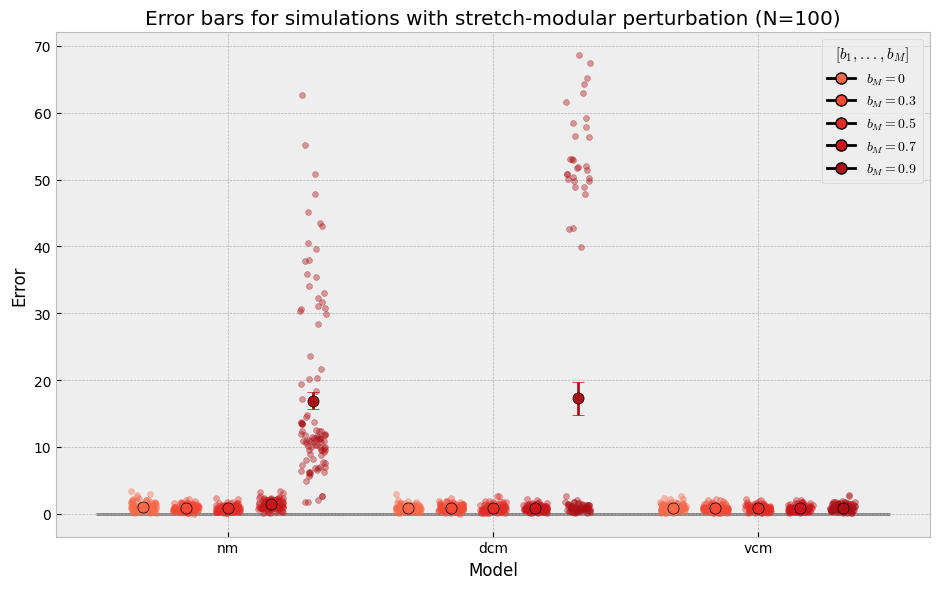

{'stretch-local-1': {'distortion': 'stretch-local', 'a': 1, 'b': 1, 'b_drift': None}, 'stretch-local-2': {'distortion': 'stretch-local', 'a': 1, 'b': 0.99, 'b_drift': None}, 'stretch-local-3': {'distortion': 'stretch-local', 'a': 1, 'b': 0.95, 'b_drift': None}, 'stretch-local-4': {'distortion': 'stretch-local', 'a': 1, 'b': 0.9, 'b_drift': None}, 'stretch-local-5': {'distortion': 'stretch-local', 'a': 1, 'b': 0.7, 'b_drift': None}}
Saved figure to simulation_outputs/round-5/figures/trajectories_stretch-local_ntrials-100.png


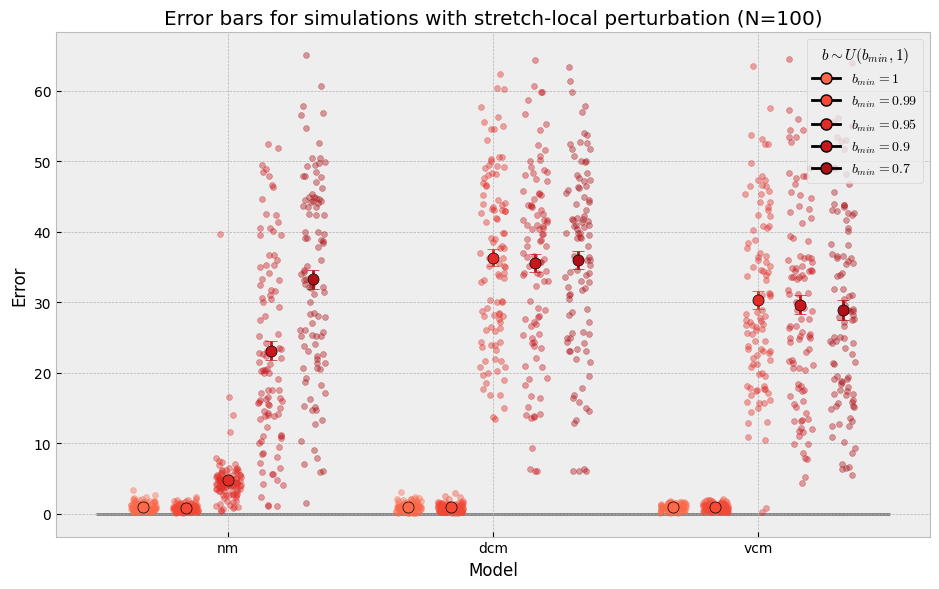

In [3]:
# ================= MODEL & SIMULATION PARAMETERS =================
N_SIM_ROUND = 5
N_TRIALS = 100
ARENA_WIDTH = 100
STEP_SIZE = 1
CONV_THRESH = STEP_SIZE * 1.5
HEX_PROJ=True
model_names = ['nm', 'dcm', 'vcm']

no_distortion_params = {'undistorted-0': {'distortion': 'none-global', 'a': None, 'b':None}}
example_distortion_params = {'undistorted-0': {'distortion': 'none-global', 'a': None, 'b':None},
                     'shear1': {'distortion': 'shear', 'a': 0, 'b': 0.3},
                     'stretch1': {'distortion': 'stretch', 'a': 1, 'b': 0.67}}

# Global distortion parameters
shear_drift_global_params = get_param_dict({'a': [0], 'b': [0, 0.3, 0.6, 1, 2, 5], 'b_drift': [0.5]}, 
                                     'shear+drift-global', incl_undistorted=False)

shear_global_params = get_param_dict({'a': [0], 'b': [0, 1, 2, 5, 10]}, 
                                     'shear-global', incl_undistorted=False)
stretch_global_params = get_param_dict({'a': [1], 'b': [1, 0.7, 0.5, 0.3, 0.1]}, 
                                       'stretch-global', incl_undistorted=False)

# Local distortion parameters
shear_local_params = get_param_dict({'a': [0], 'b': [0, 0.05, 0.1, 0.3, 0.5]}, 
                                     'shear-local', incl_undistorted=False)
stretch_local_params = get_param_dict({'a': [1], 'b': [1, 0.99, 0.95, 0.9, 0.7]}, 
                                       'stretch-local', incl_undistorted=False)

# Modular distortion parameters
shear_modular_params = get_param_dict({'a': [0], 'b': [0, 1, 2, 5, 10]}, 
                                'shear-modular', incl_undistorted=False)
stretch_modular_params = get_param_dict({'a': [1], 'b': [0, 0.3, 0.5, 0.7, 0.9]},  # WARNING: Here b_final is 1 - b, so at b=0.5 we'd have b_M's = [0.99, 0.98, 0.97, 0.96, 0.93, 0.9 , 0.85, 0.78, 0.67, 0.5 ]
                                'stretch-modular', incl_undistorted=False)
# =================================================================

for curr_distortion_params in [stretch_modular_params, stretch_local_params]:
    print(curr_distortion_params)
    run_sim = False
    if run_sim: 
        for distortion_name in curr_distortion_params.keys():
            print(F'\n {"-+" * 30} RUNNING SIMULATIONS FOR DISTORTION={distortion_name} {"-+" * 30}')
            for model_name in model_names:
                x_histories, y_histories = run_load_simulation(model_name, 
                                                            arena_width=ARENA_WIDTH, 
                                                            step_size=STEP_SIZE,
                                                            convergence_threshold=CONV_THRESH,
                                                            n_trials=N_TRIALS, 
                                                            distortion_params=curr_distortion_params[distortion_name],
                                                            hexagonal_projection=HEX_PROJ,
                                                            n_sim_round=N_SIM_ROUND,
                                                            save_data=True)

    if not run_sim:
        plot_trajectories_all_models(curr_distortion_params, 
                                model_names, 
                                arena_width=ARENA_WIDTH, 
                                step_size=STEP_SIZE, 
                                convergence_threshold=CONV_THRESH, 
                                n_trials=N_TRIALS, 
                                n_sim_round= N_SIM_ROUND,
                                save_fig=True)
        plot_error_bars(curr_distortion_params,
                        model_names,
                        n_trials=N_TRIALS, 
                        n_sim_round=N_SIM_ROUND)


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-1 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Running new simulation for ***Vector Cell Model*** with distortion=stretch-global (a=1, b=1)...
PARAMETERS:
	M=3, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	N_fvc=1250 (VCM)
	cvc_pos=[[0.         0.21052632 0.71887035],...,[  1.22721438   1.73555841   2.24390244   2.75224647   3.2605905
   3.76893453   4.27727856   4.78562259   5.29396662   5.80231065
   6.31065469   6.81899872   7.32734275   7.83568678   8.34403081
   8.85237484   9.36071887   9.8690629   10.37740693  10.88575096
  11.39409499  11.90243902  12.41078306  12.91912709  13.42747112
  13.93581515  14.44415918  14.95250321  15.46084724  15.96919127
  16.4775353   16.98587933  17.49422336  18.00256739  18.51091142
  19.01925546  19.52759949  20.03594352  20.54428755  21.05263158
  21.36842105  22.1309371   22.89345315  23.65596919

Simulating trials:  28%|██▊       | 28/100 [00:03<00:07,  9.29it/s]


KeyboardInterrupt: 

In [29]:
M = 10
scale_ratio = 1.5
b = 0.5

modular_bs = []
for i in np.arange(M, 0, -1):
    modular_bs.append(1 - round(b / (scale_ratio ** (M-i)),2))
modular_bs = np.array(modular_bs)[::-1]
modular_bs

array([0.99, 0.98, 0.97, 0.96, 0.93, 0.9 , 0.85, 0.78, 0.67, 0.5 ])

In [ ]:
plot_error_bars(distortion='shear-global', distortion_params=shear_global_params, n_trials=N_TRIALS, model_names=model_names)
plot_error_bars(distortion='shear-modular', distortion_params=shear_modular_params, n_trials=N_TRIALS, model_names=model_names)
plot_error_bars(distortion='shear-local', distortion_params=shear_local_params, n_trials=N_TRIALS, model_names=model_names)

In [2]:
arena_width = 100
n_trials = 100
border_offset = 0.05 * arena_width
square_half_width = (arena_width / 2)
offset_square_half_width = square_half_width - border_offset

XS = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
YS = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
start_locs = np.array(np.meshgrid(XS, YS)).T.reshape(-1, 2)
print('start_locs:', start_locs.shape)

print('Projecting evenly spaced start locations onto hexagonal grid axes...')
PX, PY = np.meshgrid(XS, YS)
original_grid = np.array([PX.ravel(), PY.ravel()])  # (2, N) — evenly spaced in axis space
start_locs = project_onto_axis_back(original_grid, l1=1, l2=2)  # (2, N) — parallelogram in real space
start_locs = start_locs.T  # (N, 2)
print('start_locs:', start_locs.shape)


start_locs: (100, 2)
Projecting evenly spaced start locations onto hexagonal grid axes...
start_locs: (100, 2)


### Projection of coordinate system into GC space

In [ ]:
offset_square_half_width = 10
n_trials = 10
xs = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
ys = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
XS, YS = np.meshgrid(xs, ys)
real_start_locs = np.array([XS.ravel(), YS.ravel()]).T.reshape(-1, 2)
real_start_locs


array([[-10., -10.],
       [  0.,   0.],
       [ 10.,  10.]])

In [31]:
def gc_distortion(X, Y, distortion, a=None, b=None, reverse_distortion=False):
    '''Applied distortion to X and Y coordinates.'''
    if distortion == 'stretch':
        dist_mat = np.array([[a, 0], [0, b]])
        inv_dist_mat = np.linalg.inv(dist_mat)
        X_new = inv_dist_mat[0,0]*X + inv_dist_mat[0,1]*Y
        Y_new = inv_dist_mat[1,0]*X + inv_dist_mat[1,1]*Y
        if reverse_distortion:
            X_new = dist_mat[0,0]*X + dist_mat[0,1]*Y
            Y_new = dist_mat[1,0]*X + dist_mat[1,1]*Y
    elif distortion == 'shear':
        dist_mat = np.array([[1, a], [b, 1]])
        inv_dist_mat = np.linalg.inv(dist_mat)
        X_new = inv_dist_mat[0,0]*X + inv_dist_mat[0,1]*Y
        Y_new = inv_dist_mat[1,0]*X + inv_dist_mat[1,1]*Y
        if reverse_distortion:
            X_new = dist_mat[0,0]*X + dist_mat[0,1]*Y
            Y_new = dist_mat[1,0]*X + dist_mat[1,1]*Y
    elif distortion == 'symmetric':
        X_new = X / (1 + a)
        Y_new = Y / (1 + (a * X / (1 + a)))  
    elif distortion is None or distortion == 'None':
        X_new = X
        Y_new = Y
    return X_new, Y_new

In [22]:
dist_grid_vecs

[array([25.98076211, 64.28571429]),
 array([14.43375673, 64.28571429]),
 array([ 2.88675135, 64.28571429]),
 array([-8.66025404, 64.28571429]),
 array([-20.20725942,  64.28571429]),
 array([-31.75426481,  64.28571429]),
 array([-43.30127019,  64.28571429]),
 array([-54.84827557,  64.28571429]),
 array([-66.39528096,  64.28571429]),
 array([-77.94228634,  64.28571429]),
 array([31.75426481, 50.        ]),
 array([20.20725942, 50.        ]),
 array([ 8.66025404, 50.        ]),
 array([-2.88675135, 50.        ]),
 array([-14.43375673,  50.        ]),
 array([-25.98076211,  50.        ]),
 array([-37.5277675,  50.       ]),
 array([-49.07477288,  50.        ]),
 array([-60.62177826,  50.        ]),
 array([-72.16878365,  50.        ]),
 array([37.5277675 , 35.71428571]),
 array([25.98076211, 35.71428571]),
 array([14.43375673, 35.71428571]),
 array([ 2.88675135, 35.71428571]),
 array([-8.66025404, 35.71428571]),
 array([-20.20725942,  35.71428571]),
 array([-31.75426481,  35.71428571]),
 a

In [28]:
dist_grid_vecs = np.array(dist_grid_vecs)
dist_grid_vecs[:,0]


array([ 25.98076211,  14.43375673,   2.88675135,  -8.66025404,
       -20.20725942, -31.75426481, -43.30127019, -54.84827557,
       -66.39528096, -77.94228634,  31.75426481,  20.20725942,
         8.66025404,  -2.88675135, -14.43375673, -25.98076211,
       -37.5277675 , -49.07477288, -60.62177826, -72.16878365,
        37.5277675 ,  25.98076211,  14.43375673,   2.88675135,
        -8.66025404, -20.20725942, -31.75426481, -43.30127019,
       -54.84827557, -66.39528096,  43.30127019,  31.75426481,
        20.20725942,   8.66025404,  -2.88675135, -14.43375673,
       -25.98076211, -37.5277675 , -49.07477288, -60.62177826,
        49.07477288,  37.5277675 ,  25.98076211,  14.43375673,
         2.88675135,  -8.66025404, -20.20725942, -31.75426481,
       -43.30127019, -54.84827557,  54.84827557,  43.30127019,
        31.75426481,  20.20725942,   8.66025404,  -2.88675135,
       -14.43375673, -25.98076211, -37.5277675 , -49.07477288,
        60.62177826,  49.07477288,  37.5277675 ,  25.98

In [25]:
proj_grid

array([[-25.98076211, -14.43375673,  -2.88675135,   8.66025404,
         20.20725942,  31.75426481,  43.30127019,  54.84827557,
         66.39528096,  77.94228634, -31.75426481, -20.20725942,
         -8.66025404,   2.88675135,  14.43375673,  25.98076211,
         37.5277675 ,  49.07477288,  60.62177826,  72.16878365,
        -37.5277675 , -25.98076211, -14.43375673,  -2.88675135,
          8.66025404,  20.20725942,  31.75426481,  43.30127019,
         54.84827557,  66.39528096, -43.30127019, -31.75426481,
        -20.20725942,  -8.66025404,   2.88675135,  14.43375673,
         25.98076211,  37.5277675 ,  49.07477288,  60.62177826,
        -49.07477288, -37.5277675 , -25.98076211, -14.43375673,
         -2.88675135,   8.66025404,  20.20725942,  31.75426481,
         43.30127019,  54.84827557, -54.84827557, -43.30127019,
        -31.75426481, -20.20725942,  -8.66025404,   2.88675135,
         14.43375673,  25.98076211,  37.5277675 ,  49.07477288,
        -60.62177826, -49.07477288, -37.

In [24]:
# Get rid of extra dim
[vec for vec in dist_grid_vecs]

[array([25.98076211, 64.28571429]),
 array([14.43375673, 64.28571429]),
 array([ 2.88675135, 64.28571429]),
 array([-8.66025404, 64.28571429]),
 array([-20.20725942,  64.28571429]),
 array([-31.75426481,  64.28571429]),
 array([-43.30127019,  64.28571429]),
 array([-54.84827557,  64.28571429]),
 array([-66.39528096,  64.28571429]),
 array([-77.94228634,  64.28571429]),
 array([31.75426481, 50.        ]),
 array([20.20725942, 50.        ]),
 array([ 8.66025404, 50.        ]),
 array([-2.88675135, 50.        ]),
 array([-14.43375673,  50.        ]),
 array([-25.98076211,  50.        ]),
 array([-37.5277675,  50.       ]),
 array([-49.07477288,  50.        ]),
 array([-60.62177826,  50.        ]),
 array([-72.16878365,  50.        ]),
 array([37.5277675 , 35.71428571]),
 array([25.98076211, 35.71428571]),
 array([14.43375673, 35.71428571]),
 array([ 2.88675135, 35.71428571]),
 array([-8.66025404, 35.71428571]),
 array([-20.20725942,  35.71428571]),
 array([-31.75426481,  35.71428571]),
 a

In [ ]:
normal_grid_vecs = np.array(normal_grid_vecs)
normal_grid_vecs.shape

(100, 2)

In [52]:
real_grid_diff.shape

(2, 100)

This should match my original start locations:


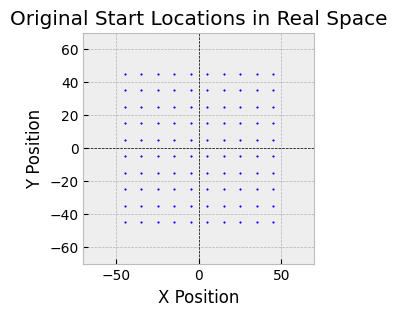

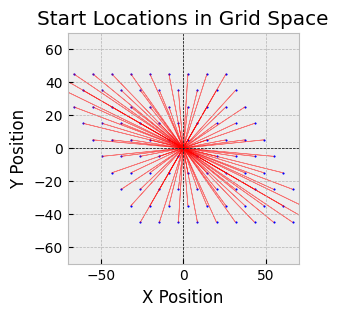

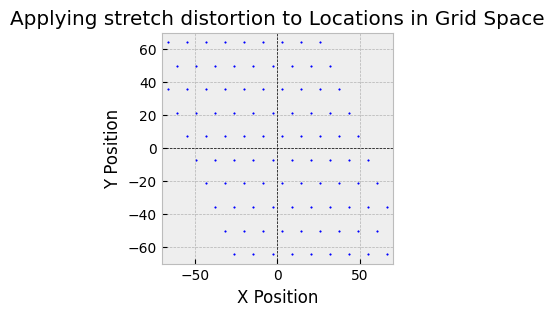

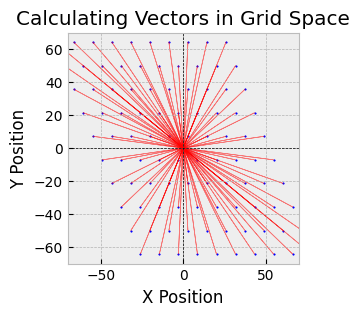

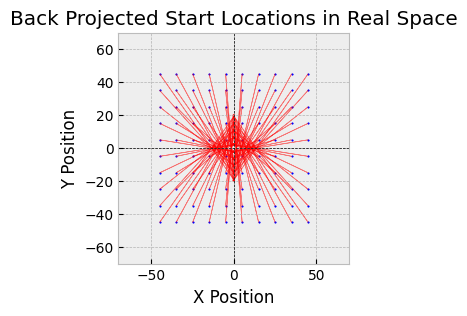

In [61]:
def plot_start_locations(X, Y, square_half_width, all_vecs = None, plot_vecs = False, title='Start Locations in Arena', distortion=False):
    plt.figure(figsize=(3, 3))
    if distortion == True and 'Grid Space' in title:
        X, Y = gc_distortion(X, Y, distortion='stretch', a=1, b=0.7)
    plt.scatter(X, Y, c='blue', label='Start Locations', s=1)
    box_lim = 70
    plt.xlim(-box_lim, box_lim)
    plt.ylim(-box_lim, box_lim)
    # Calculate vector from each point to [0,0]
    no_loaded_all_vecs = all_vecs is None
    all_vecs = [] if no_loaded_all_vecs else all_vecs
    if plot_vecs:
        for i, (x, y) in enumerate(zip(X, Y)):
            if no_loaded_all_vecs:
                my_vec = - np.array([x, y])
                all_vecs.append(my_vec)
            else:
                my_vec = all_vecs[i]

                # Apply reverse distortion to the vector if distortion is applied
            #    if distortion:
            #        my_vec[0], my_vec[1] = gc_distortion(my_vec[0], my_vec[1], distortion='stretch', a=1, b=0.6, reverse_distortion=True)
                # normalize
            plt.arrow(x, y, my_vec[0], my_vec[1], head_width=1, head_length=1, fc='red', ec='red', alpha=0.5)
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.title(title)
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True)
    return all_vecs

    
# 1. Grid of start locations in real space
arena_width = 100
n_trials = 100

square_half_width = (arena_width / 2)
offset = 0.1 * square_half_width  # to avoid points on the edge

# Generate pos_xy_mat
XS = np.linspace(-square_half_width + offset, square_half_width - offset, int(np.sqrt(n_trials)))
YS = np.linspace(-square_half_width + offset, square_half_width - offset, int(np.sqrt(n_trials)))
PX, PY = np.meshgrid(XS, YS)
original_grid = np.array([PX.ravel(), PY.ravel()])  # (2, N) — evenly spaced in axis space
_ = plot_start_locations(original_grid[0, :], original_grid[1, :], square_half_width, title='Original Start Locations in Real Space')

# Convert to real 2D positions to pass to navigation
proj_grid = real_to_grid_projection(original_grid, l1=1, l2=2)  # (2, N) — parallelogram in real space
real_grid_diff = original_grid - proj_grid

normal_grid_vecs = plot_start_locations(proj_grid[0, :], proj_grid[1, :], square_half_width,  plot_vecs=True, title='Start Locations in Grid Space')

_ = plot_start_locations(proj_grid[0, :], proj_grid[1, :], square_half_width, title='Applying stretch distortion to Locations in Grid Space', distortion= True)

grid_vecs = plot_start_locations(proj_grid[0, :], proj_grid[1, :], square_half_width, plot_vecs=True, title='Calculating Vectors in Grid Space', distortion= True)

print('This should match my original start locations:')
#normal_grid_vecs = grid_to_real_projection(normal_grid_vecs)

grid_vecs = np.array(grid_vecs)
corrected_normal_grid_vecs = grid_vecs - real_grid_diff.T

back_original_grid = grid_to_real_projection(proj_grid)
_ = plot_start_locations(back_original_grid[0, :], back_original_grid[1, :], square_half_width, all_vecs=corrected_normal_grid_vecs, plot_vecs=True, title='Back Projected Start Locations in Real Space')


In [62]:
border_offset = 0.05 * arena_width
square_half_width = (arena_width / 2)
offset_square_half_width = square_half_width - border_offset
xs = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
ys = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
XS, YS = np.meshgrid(xs, ys)
real_start_locs = np.array([XS.ravel(), YS.ravel()]).T.reshape(-1, 2)
real_start_locs.shape

(100, 2)


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-1 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 75.85it/s]


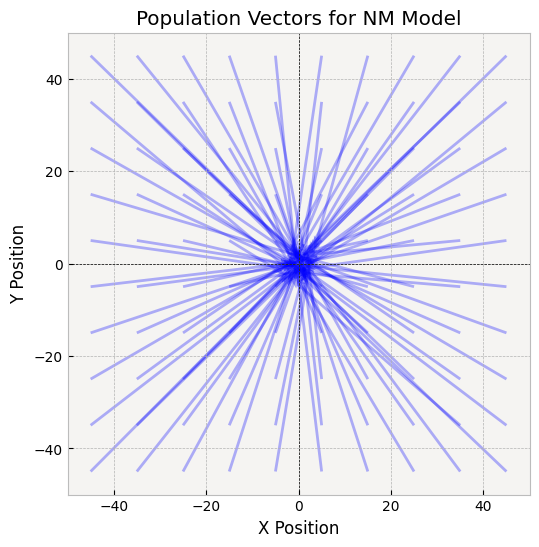


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-2 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 75.71it/s]


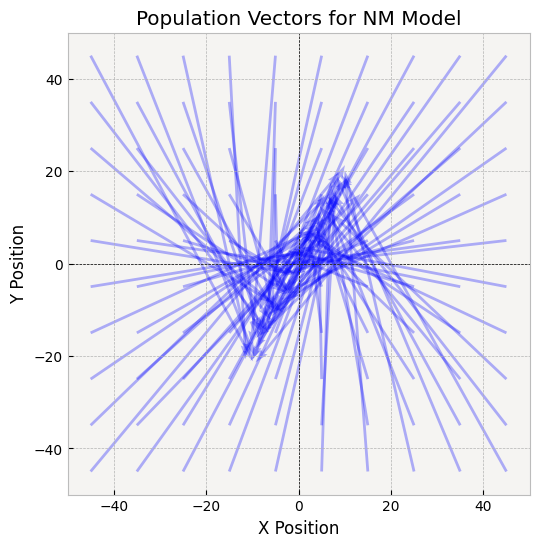


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-3 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 76.38it/s]


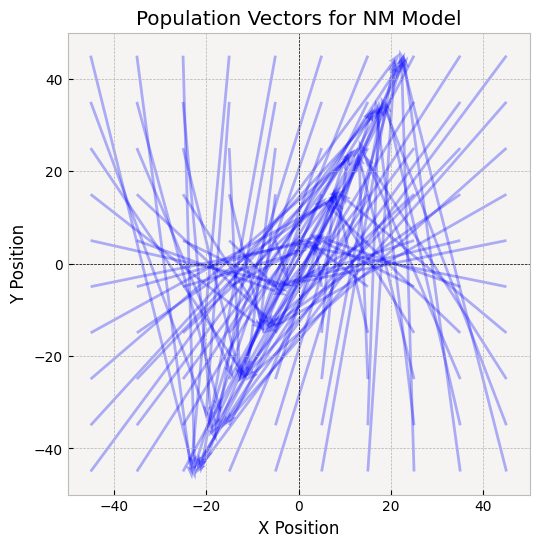


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-4 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 76.74it/s]


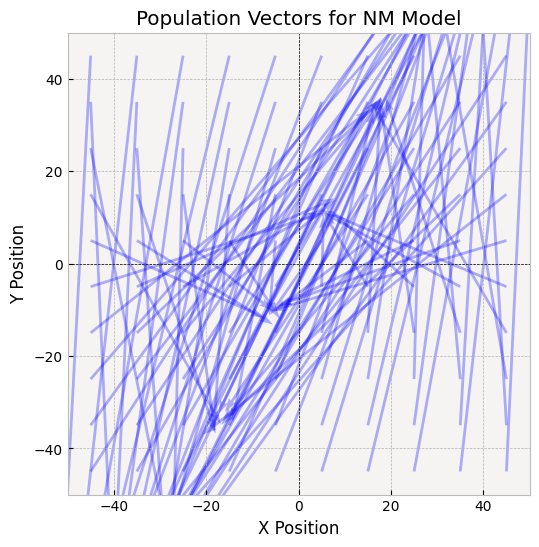


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-5 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 76.51it/s]


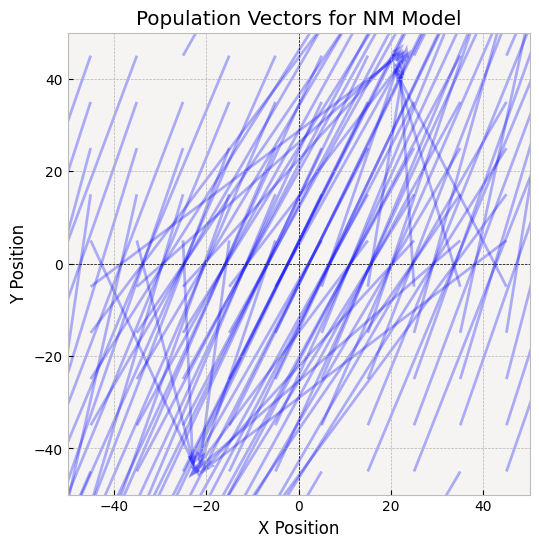

In [23]:
import numpy as np
from math import pow
import matplotlib.pyplot as plt
plt.style.use('bmh')
# Set background color to antique white
plt.rcParams['axes.facecolor'] = "#F5F4F2"
import os
from utils import *
from utils import grid_to_real_projection
from simulation import *
from tqdm import tqdm
from pprint import pprint

from models import DistanceCellModel, VectorCellModel, NestedModel
from simulation import run_load_simulation
OUTPUT_DIR = 'simulation_outputs'

N_SIM_ROUND = 5
N_TRIALS = 100
ARENA_WIDTH = 100
STEP_SIZE = 1
CONV_THRESH = STEP_SIZE * 1.5
HEX_PROJ=True
model_names = ['nm', 'dcm', 'vcm']


def pop_vec_simulation(model_name, arena_width, n_trials=400, step_size=0.1, convergence_threshold = 2.5, distortion_params = None, hexagonal_projection=False, n_sim_round=1, save_data=True):

    # Directories
    output_dir = Path('simulation_outputs', f'round-{n_sim_round}')
    distortion, a, b = distortion_params['distortion'], distortion_params['a'], distortion_params['b']
    distortion_type = distortion.split('-')[1]
    distortion_text = f'_{distortion}_a-{a}_b-{b}' if distortion is not None else '_undistorted'
    if '+drift' in distortion:
        distortion_text += f'_bdrift-{distortion_params["b_drift"]}'

    #Initialize corresponding model
    if model_name == 'dcm':
        model = DistanceCellModel(distortion_params=distortion_params)
    elif model_name == 'vcm':
        model = VectorCellModel(distortion_params=distortion_params, arena_width = arena_width)
    elif model_name == 'nm':
        model = NestedModel(distortion_params=distortion_params)
    else:
        raise ValueError("Invalid model name")


    # Get evenly spaced start positions in real space
    border_offset = 0.05 * arena_width
    square_half_width = (arena_width / 2)
    offset_square_half_width = square_half_width - border_offset
    xs = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
    ys = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
    XS, YS = np.meshgrid(xs, ys)
    real_start_locs = np.array([XS.ravel(), YS.ravel()]).T.reshape(-1, 2)

    # Get start positions in grid space
    if hexagonal_projection:
        grid_start_locs = real_to_grid_projection(np.array([XS.ravel(), YS.ravel()]) , l1=1, l2=2).T  
    
    # For each trial...
    pop_vec_histories = []
    for i in tqdm(range(n_trials), desc="Simulating trials"):

        # 1) Get start and goal positions 
        real_start_x, real_start_y = real_start_locs[i]
        grid_start_x, grid_start_y = grid_start_locs[i] if hexagonal_projection else (real_start_x, real_start_y)
        goal_x, goal_y = [0, 0] # Goal is the same in real and grid space
 
        # Compute the population vector based on the current position and the goal
        grid_start_x, grid_start_y = real_to_grid_projection([real_start_x, real_start_y]) if hexagonal_projection else (real_start_x, real_start_y)
        curr_pop_vec = model.forward(start_pos=[grid_start_x, grid_start_y], targ_pos=[goal_x, goal_y])
        curr_pop_vec = grid_to_real_projection(curr_pop_vec) if hexagonal_projection else curr_pop_vec
        pop_vec_histories.append(curr_pop_vec)

    # Plot pop_vec_histories
    pop_vec_histories = np.array(pop_vec_histories)
    plt.figure(figsize=(6, 6))
    plt.quiver(real_start_locs[:, 0], real_start_locs[:, 1], pop_vec_histories[:, 0], pop_vec_histories[:, 1], angles='xy', scale_units='xy', color='blue', alpha=0.3, scale=1)
  #  plt.scatter(real_start_locs[:, 0] - pop_vec_histories[:, 0],real_start_locs[:, 1] - pop_vec_histories[:, 1], c='red', s=1, label='Population Vector Endpoints')


    plt.xlim(-square_half_width, square_half_width)
    plt.ylim(-square_half_width, square_half_width)
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.title(f'Population Vectors for {model_name.upper()} Model')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True)
    plt.show()
stretch_global_params = get_param_dict({'a': [1], 'b': [1, 0.7, 0.5, 0.3, 0.1]}, 
                                       'stretch-global', incl_undistorted=False)

selected_distortion_params = stretch_global_params
for distortion_name in selected_distortion_params.keys():
    print(F'\n {"-+" * 30} RUNNING SIMULATIONS FOR DISTORTION={distortion_name} {"-+" * 30}')
    for model_name in ['nm']:
        pop_vec_simulation(model_name, 
                            arena_width=ARENA_WIDTH, 
                            step_size=STEP_SIZE,
                            convergence_threshold=CONV_THRESH,
                            n_trials=100, 
                            distortion_params=selected_distortion_params[distortion_name],
                            hexagonal_projection=True,
                            n_sim_round= N_SIM_ROUND,
                            save_data=False)